## **Analisis Komparasi Algoritma YOLO, SSD, dan Faster R-CNN untuk Deteksi Objek Pelanggaran Truk ODOL (Over Dimension Overload)**

**YOLOv8n**

In [ ]:
# Mount Google Drive untuk penyimpanan permanen
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CELL 1: INSTALL LIBRARY & DOWNLOAD DATASET

In [ ]:
!pip install ultralytics roboflow

from roboflow import Roboflow
import os

# PENTING: Ganti dengan API Key dari akun Roboflow kamu
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mr4rN1CwX8na9vGEIdNh")
project = rf.workspace("indahs-workspace").project("data-indah")
version = project.version(2)
dataset = version.download("yolov8")

print("Dataset berhasil diunduh ke lokasi:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data-indah-2 in yolov8:: 100%|██████████| 2865/2865 [00:00<00:00, 5778.45it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset berhasil diunduh ke lokasi: /content/data-indah-2


CELL 2: EXPLORATORY DATA ANALYSIS (EDA) VISUAL

📊 Memulai Proses Analisis Data Visual...



Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.


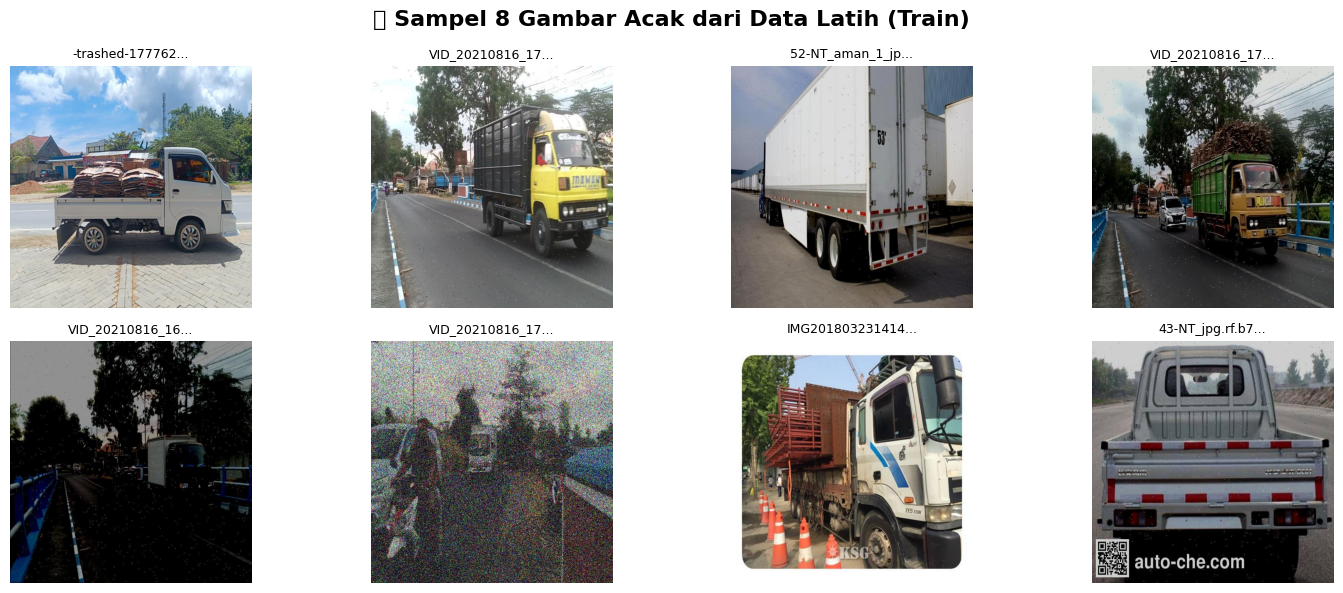

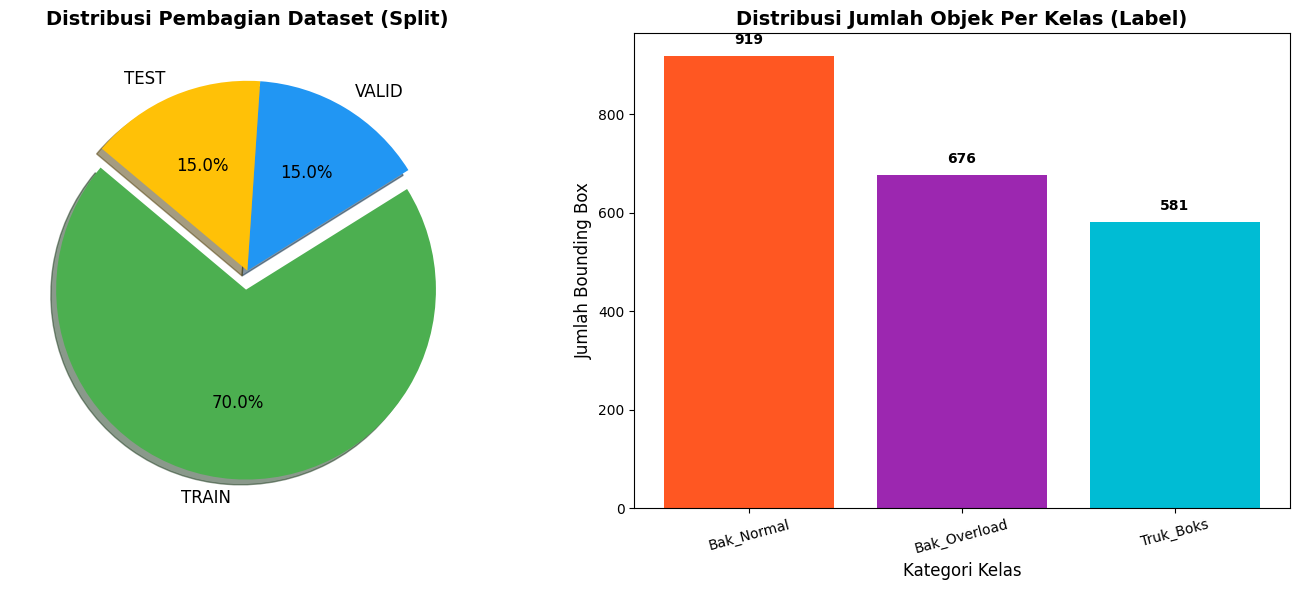


📝 RINGKASAN DATASET:
- Total Kelas Deteksi : 3 Kelas (Bak_Normal, Bak_Overload, Truk_Boks)
- Total Gambar Train  : 1001 gambar
- Total Gambar Valid  : 215 gambar
- Total Gambar Test   : 214 gambar


In [ ]:
import os
import glob
import random
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = dataset.location

print("📊 Memulai Proses Analisis Data Visual...\n")

# ==========================================
# 1. VISUALISASI 8 GAMBAR ACAK DARI DATA TRAIN
# ==========================================
train_images = glob.glob(f"{dataset_path}/train/images/*.jpg")

if len(train_images) >= 8:
    gambar_acak = random.sample(train_images, 8)

    plt.figure(figsize=(15, 6))
    plt.suptitle("📸 Sampel 8 Gambar Acak dari Data Latih (Train)", fontsize=16, fontweight='bold')

    for i, img_path in enumerate(gambar_acak):
        img = mpimg.imread(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        # Menampilkan nama file sebagai judul kecil
        plt.title(os.path.basename(img_path)[:15] + "...", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Gambar di folder Train kurang dari 8 untuk ditampilkan.")

# ==========================================
# 2. PIE CHART: DISTRIBUSI SPLIT (TRAIN, VALID, TEST)
# ==========================================
splits = ['train', 'valid', 'test']
split_counts = []

for split in splits:
    img_dir = f"{dataset_path}/{split}/images"
    if os.path.exists(img_dir):
        split_counts.append(len(os.listdir(img_dir)))
    else:
        split_counts.append(0)

plt.figure(figsize=(14, 6))

# Plot Pie Chart (Sebelah Kiri)
plt.subplot(1, 2, 1)
colors_pie = ['#4CAF50', '#2196F3', '#FFC107']
explode = (0.1, 0, 0)  # Menonjolkan potongan Train
plt.pie(split_counts, labels=[s.upper() for s in splits], autopct='%1.1f%%',
        startangle=140, colors=colors_pie, explode=explode, shadow=True, textprops={'fontsize': 12})
plt.title("Distribusi Pembagian Dataset (Split)", fontsize=14, fontweight='bold')

# ==========================================
# 3. BAR CHART: DISTRIBUSI JUMLAH OBJEK PER KELAS
# ==========================================
# Membaca nama kelas dari file data.yaml bawaan Roboflow
yaml_path = f"{dataset_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
# Menyiapkan dictionary untuk menghitung setiap kelas
class_counts = {name: 0 for name in class_names}

# Membaca seluruh file label .txt di semua split untuk menghitung bounding box
for split in splits:
    label_files = glob.glob(f"{dataset_path}/{split}/labels/*.txt")
    for file in label_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0]) # Mengambil ID kelas di awal baris
                class_counts[class_names[class_id]] += 1

# Plot Bar Chart (Sebelah Kanan)
plt.subplot(1, 2, 2)
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#FF5722', '#9C27B0', '#00BCD4'])
plt.title("Distribusi Jumlah Objek Per Kelas (Label)", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Kelas", fontsize=12)
plt.ylabel("Jumlah Bounding Box", fontsize=12)
plt.xticks(rotation=15) # Memiringkan teks agar tidak bertumpuk

# Menambahkan angka di atas masing-masing batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(class_counts.values())*0.02),
             int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print ringkasan berupa teks
print("\n📝 RINGKASAN DATASET:")
print(f"- Total Kelas Deteksi : {len(class_names)} Kelas ({', '.join(class_names)})")
print(f"- Total Gambar Train  : {split_counts[0]} gambar")
print(f"- Total Gambar Valid  : {split_counts[1]} gambar")
print(f"- Total Gambar Test   : {split_counts[2]} gambar")

CELL 4: Pre-processing Data

In [ ]:
img_size = 640

# Kita juga pastikan file data.yaml terbaca dengan baik
yaml_path = f"{dataset.location}/data.yaml"
print(f"Preprocessing siap! Resolusi gambar disetel ke: {img_size}x{img_size}")
print(f"File konfigurasi kelas berada di: {yaml_path}")

Preprocessing siap! Resolusi gambar disetel ke: 640x640
File konfigurasi kelas berada di: /content/data-indah-2/data.yaml


In [ ]:
!pip install ultralytics

CELL 5: Pelatihan Model (Training) YOLOv8 Nano

In [ ]:
from ultralytics import YOLO
import os

# 1. Pastikan lokasi file konfigurasi YAML benar
# Menggunakan path langsung ke folder dataset kamu
yaml_path = '/content/data-indah-2/data.yaml'
print(f"Menggunakan konfigurasi data dari: {yaml_path}")

# 2. Memuat arsitektur dasar YOLOv8 Nano
print("Memuat arsitektur YOLOv8 Nano...")
model = YOLO('yolov8n.pt')

# 3. Eksekusi Training
print("Memulai proses training... (Estimasi waktu: 15-30 menit)")
results = model.train(
    data=yaml_path,
    epochs=30,               # Jumlah putaran belajar
    imgsz=640,               # Resolusi gambar
    batch=16,                # Memproses 16 gambar sekaligus
    lr0=0.001,               # Learning rate awal
    dropout=0.1,             # Mencegah model sekadar "menghafal" data training
    device=0,                # Wajib 0 agar menggunakan GPU (T4)

    # Lokasi penyimpanan hasil (Aman di Google Drive)
    project='/content/drive/MyDrive/Evaluasi_ODOL',
    name='YOLOv8_Hasil'
)

print("\nProses Training Selesai! Model terbaik telah disimpan.")

Menggunakan konfigurasi data dari: /content/data-indah-2/data.yaml
Memuat arsitektur YOLOv8 Nano...
Memulai proses training... (Estimasi waktu: 15-30 menit)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data-indah-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n

CELL 6: Visualisasi Hasil Pelatihan

📊 Memulai visualisasi grafik...

=== RESULTS.PNG ===


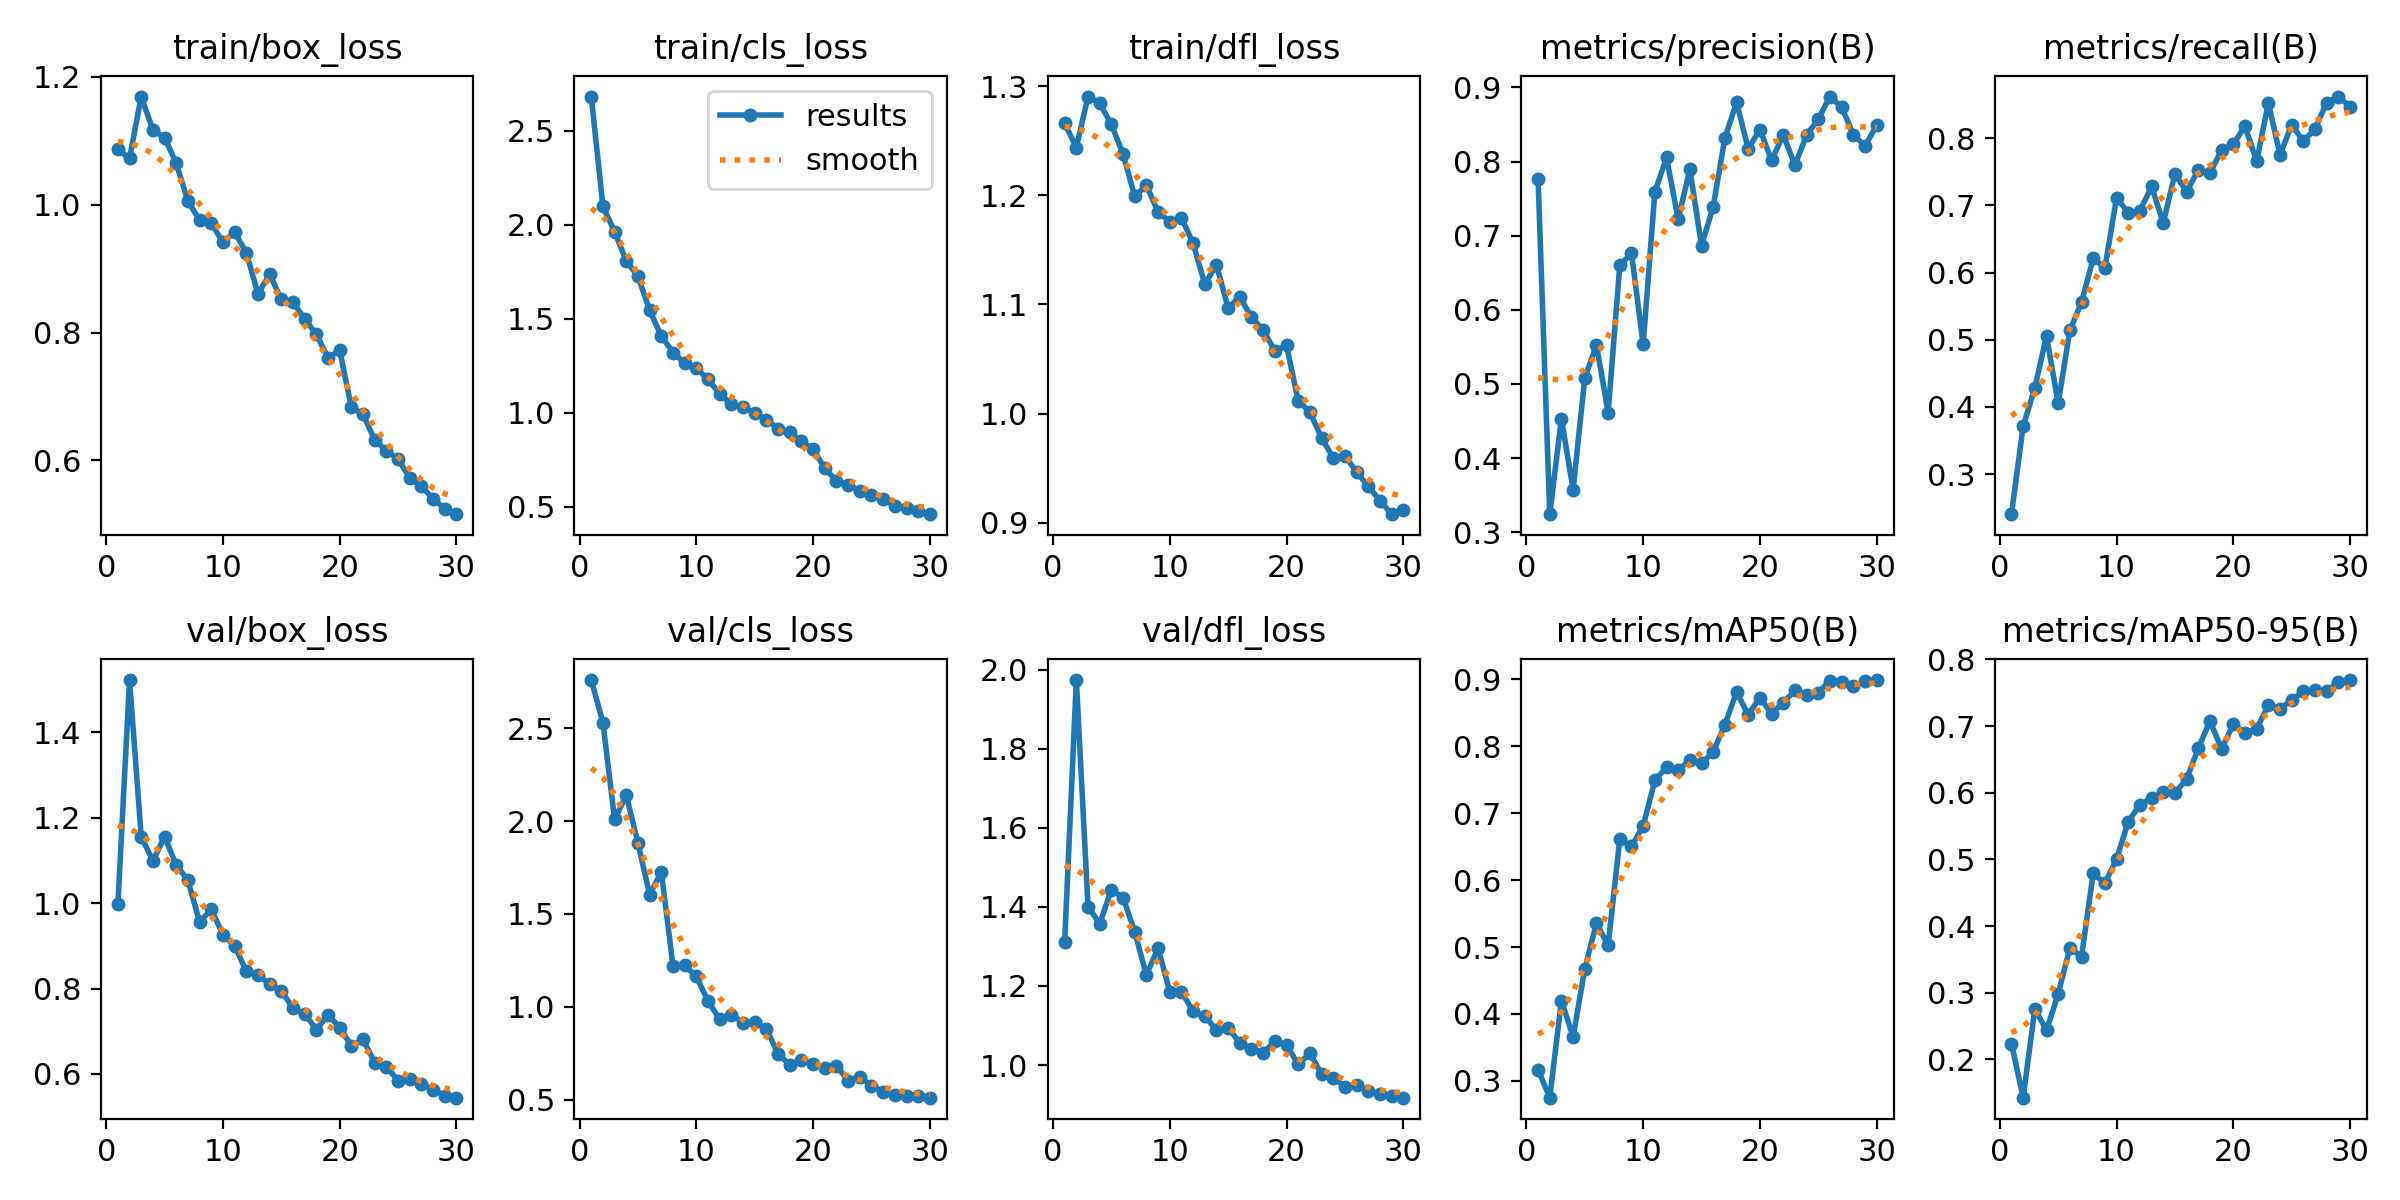


--------------------------------------------------

=== CONFUSION_MATRIX.PNG ===


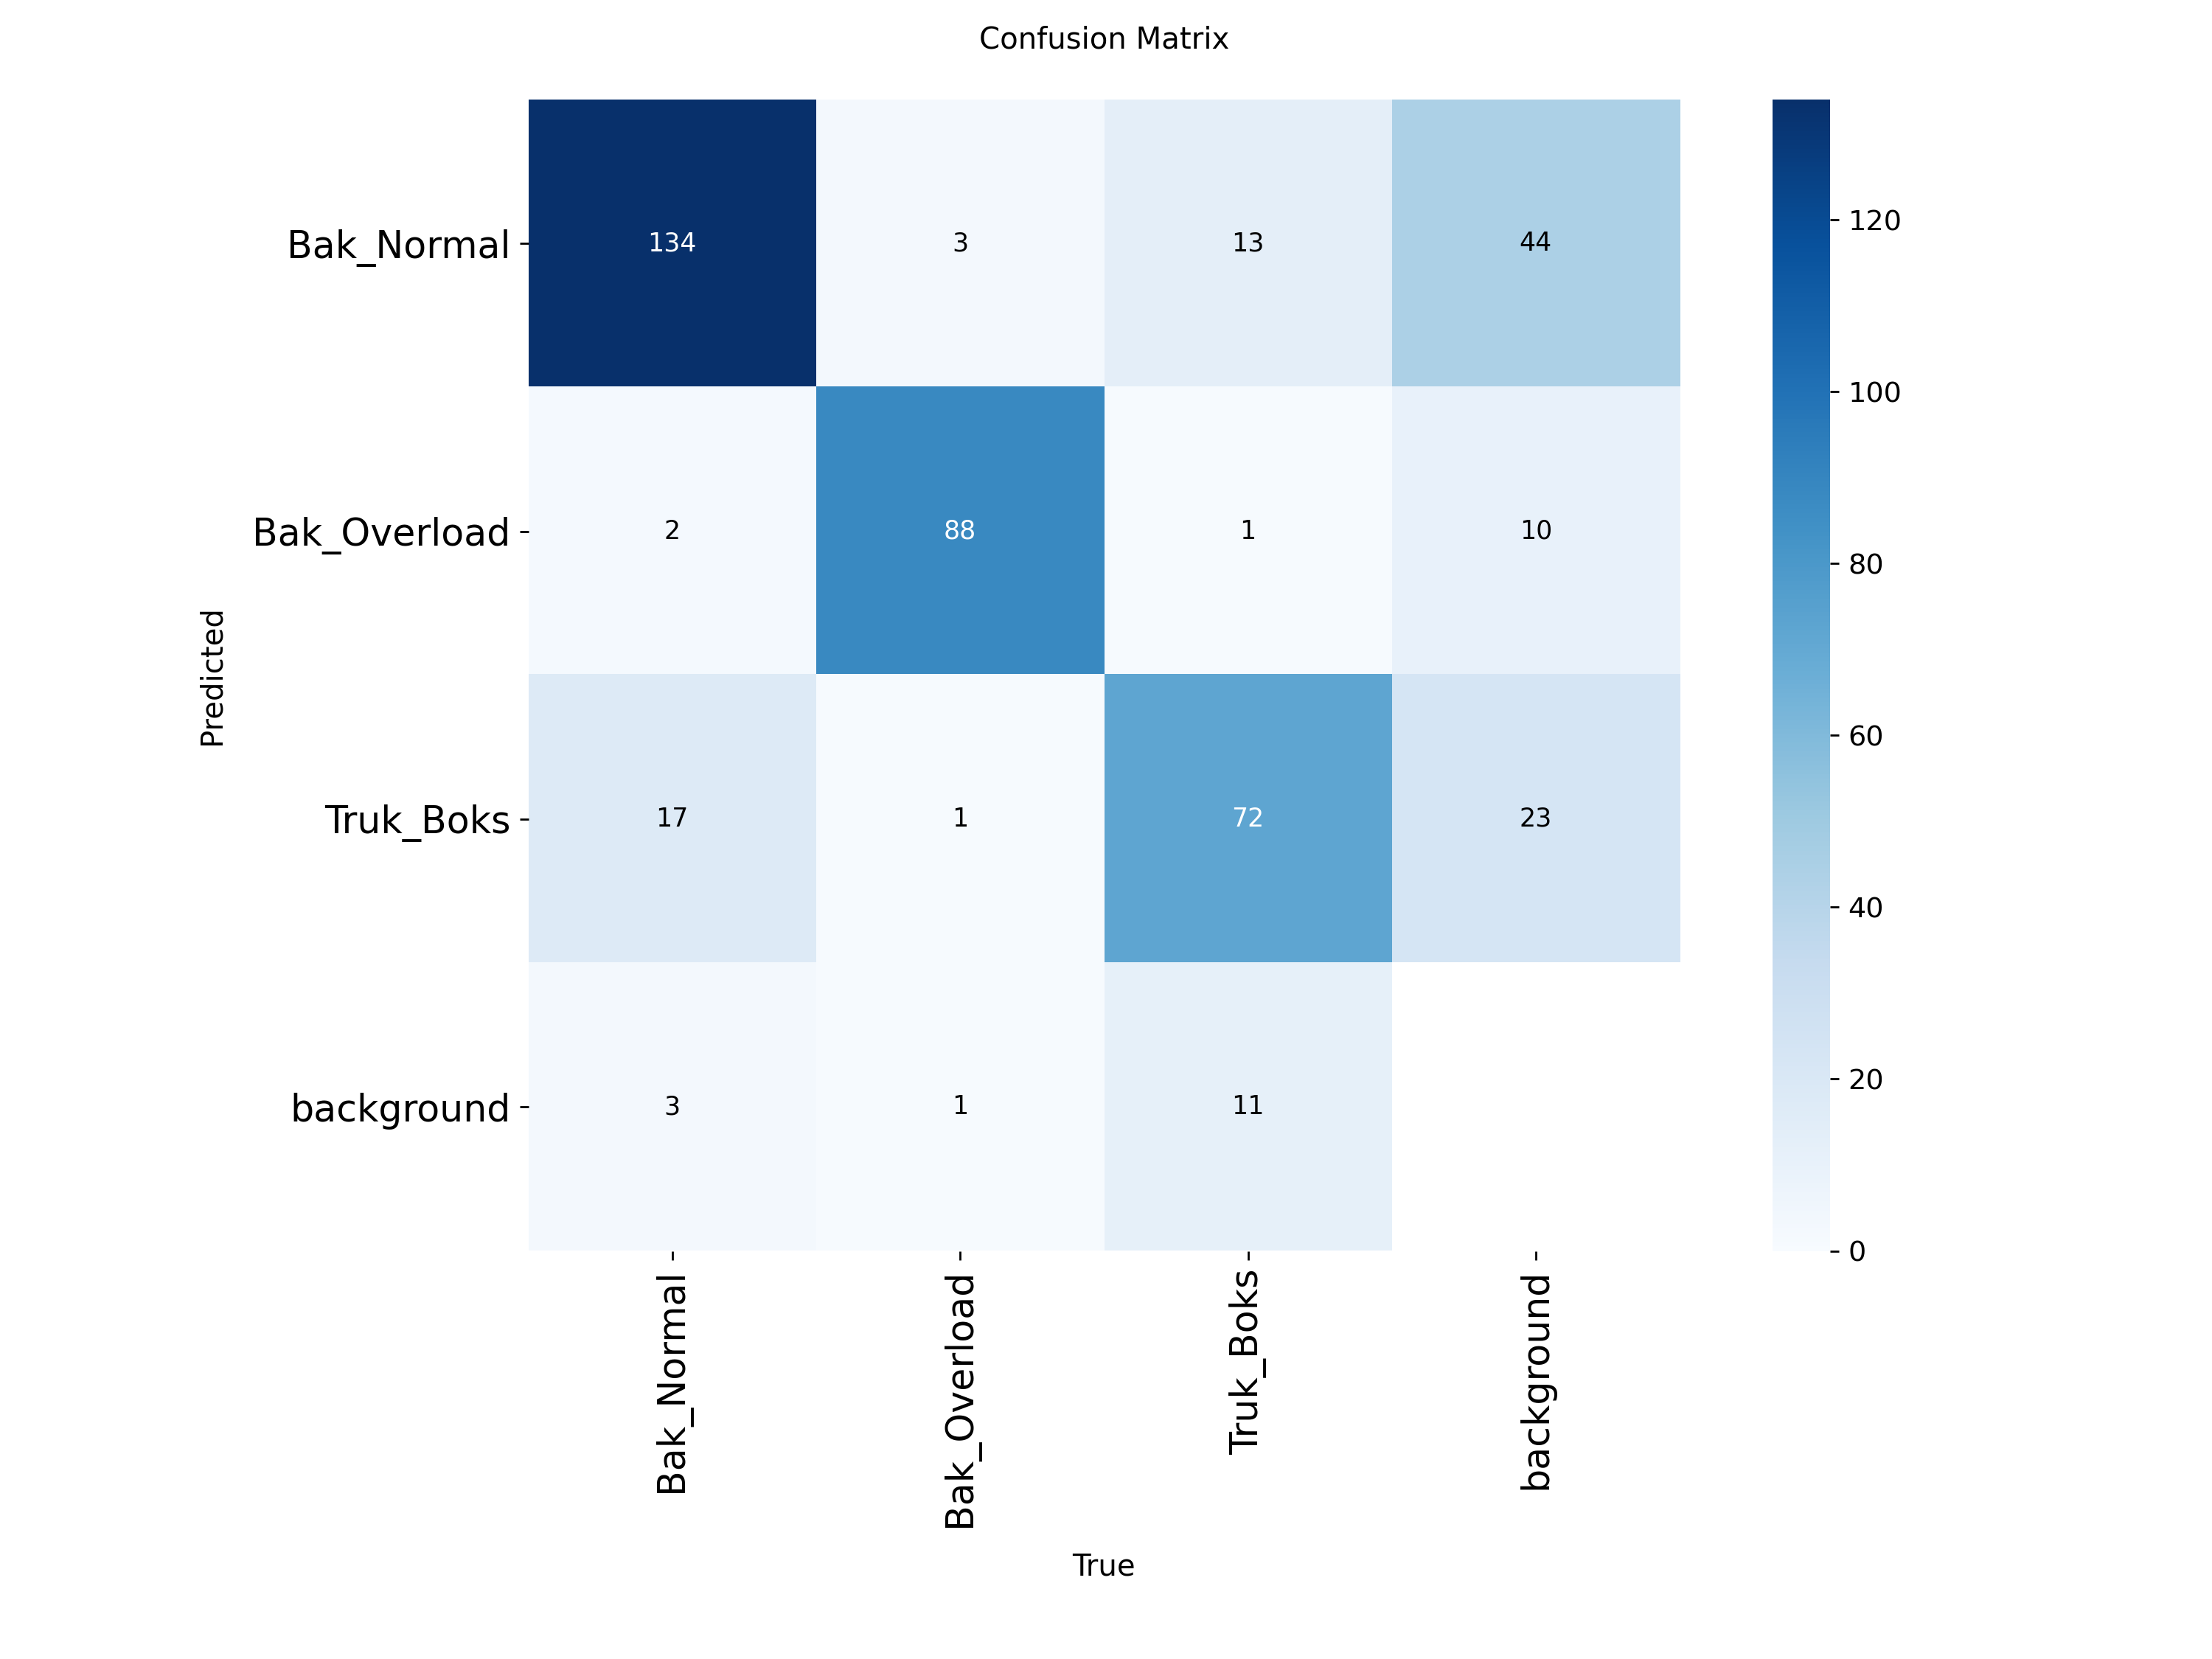


--------------------------------------------------

=== CONFUSION_MATRIX_NORMALIZED.PNG ===


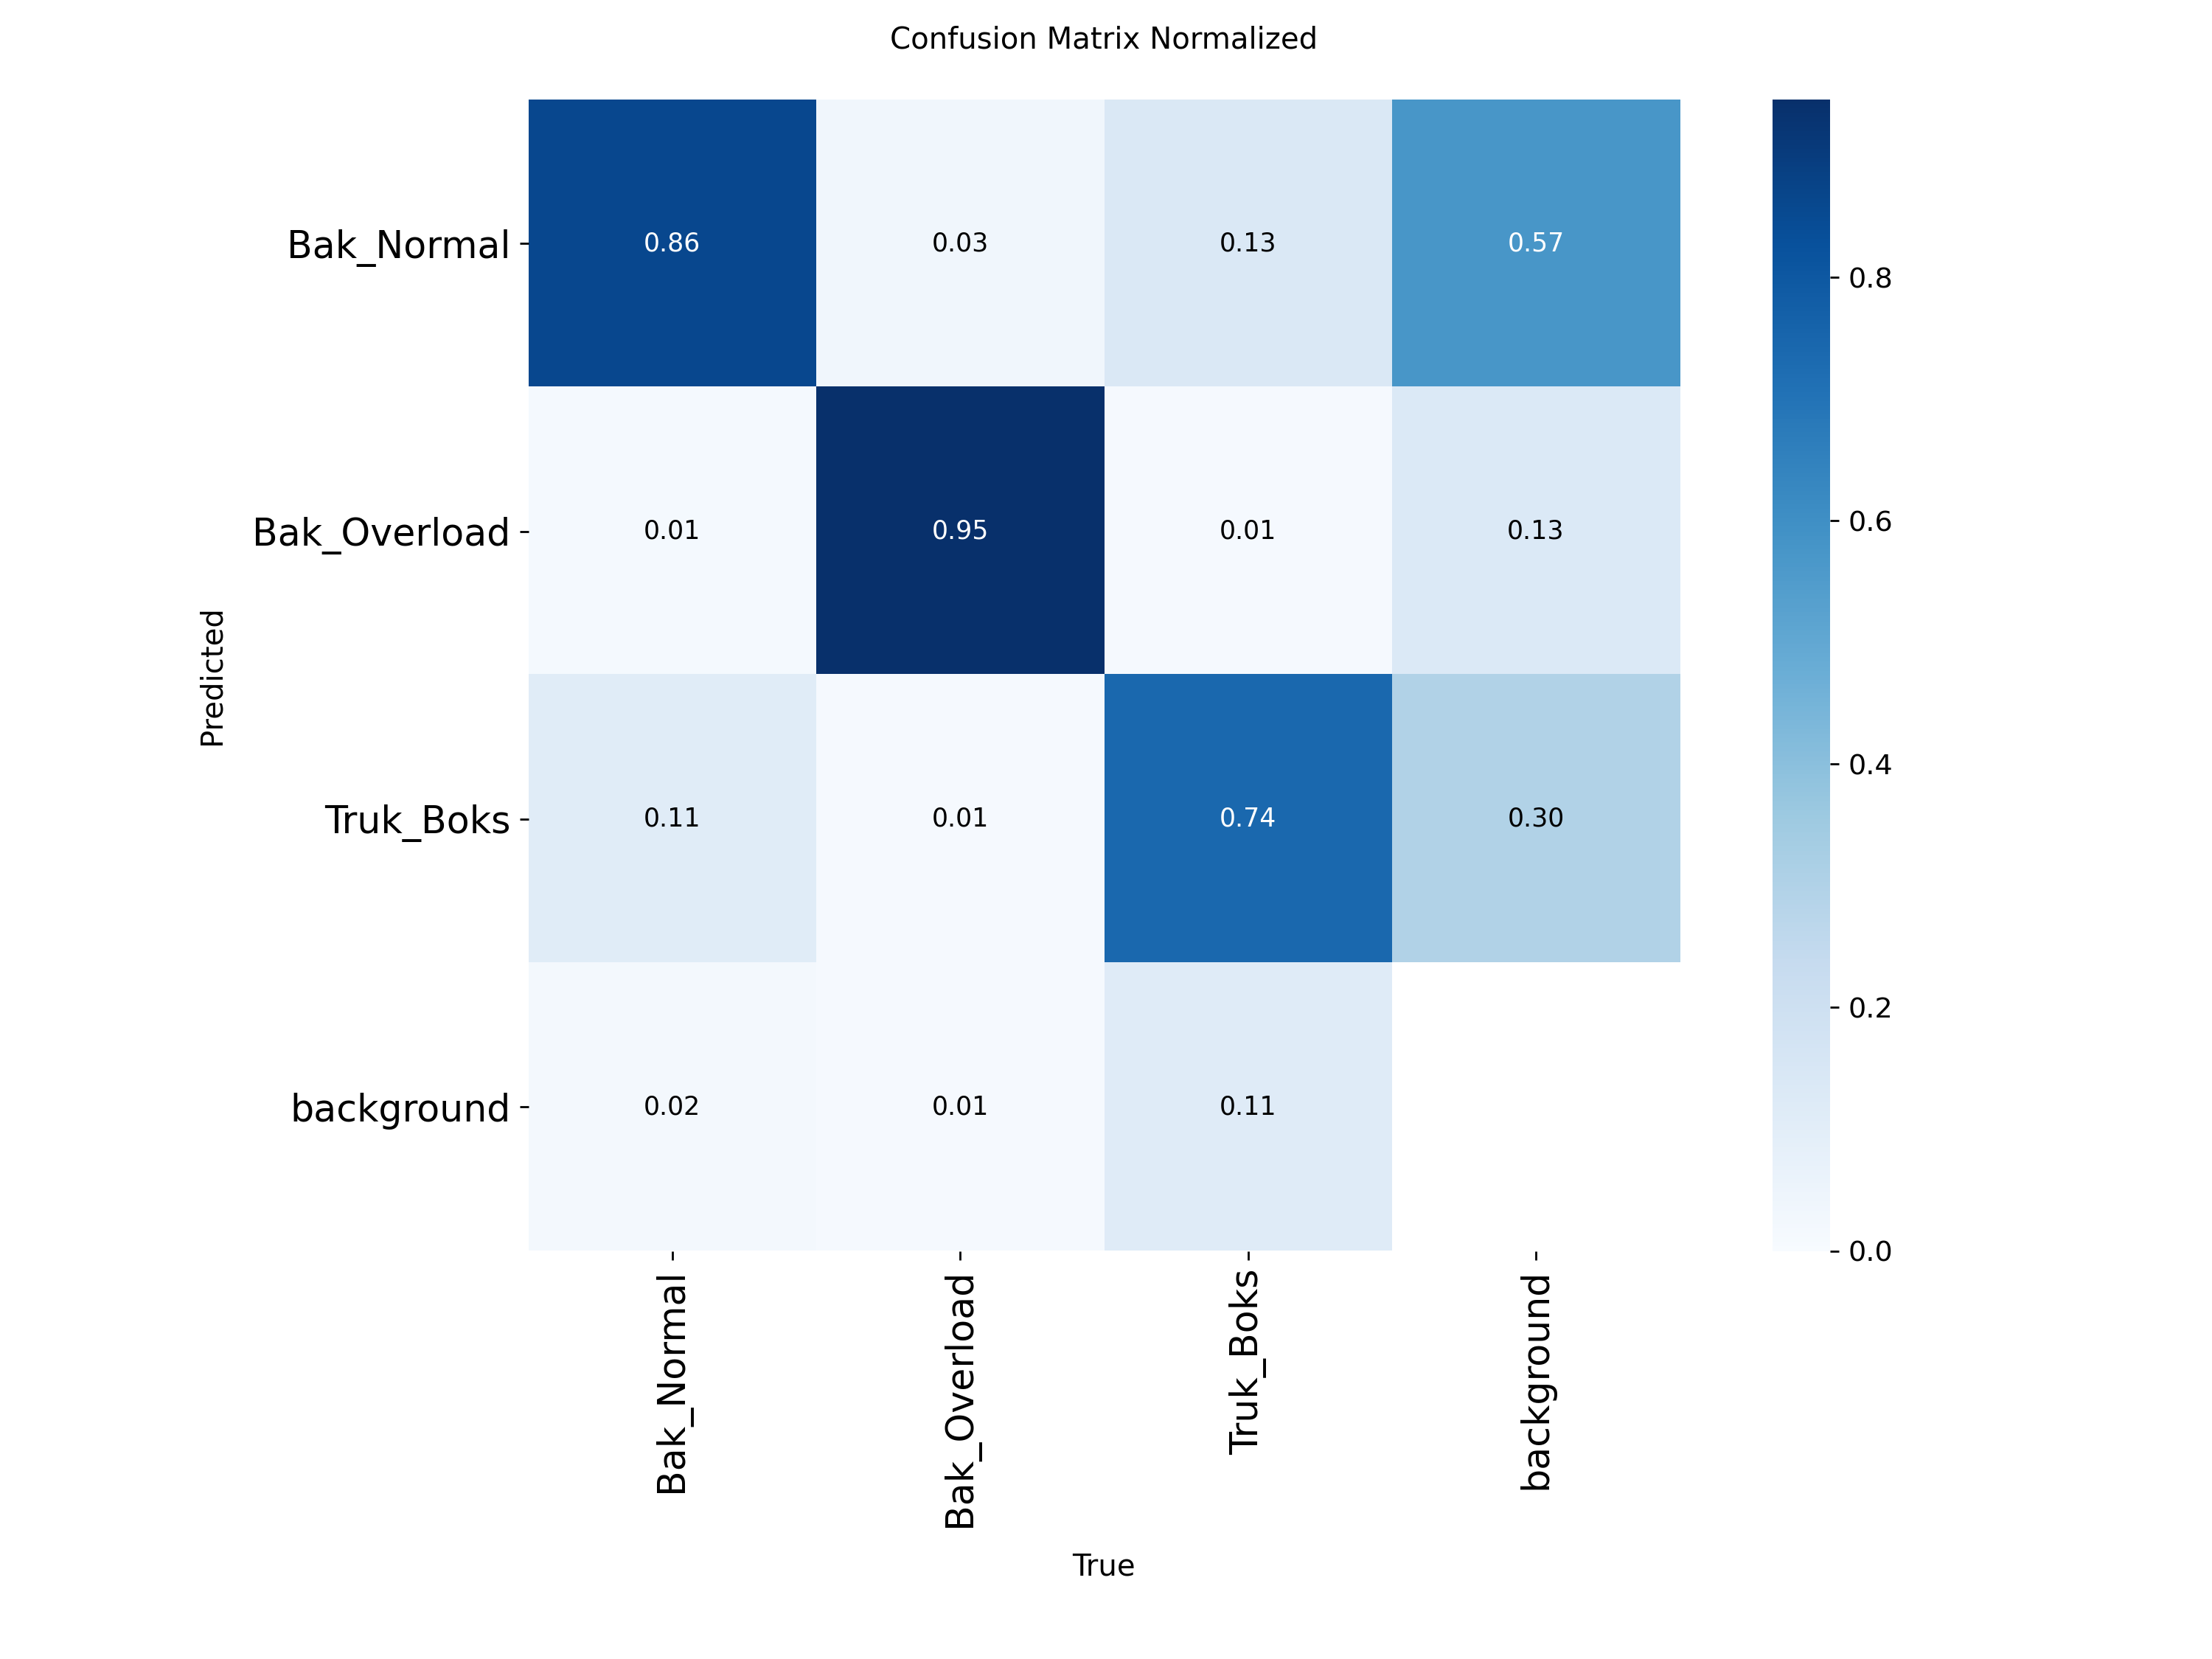


--------------------------------------------------

✅ Berhasil menampilkan 3 grafik utama.


In [ ]:
import os
from IPython.display import Image, display

# Path folder hasil training di Google Drive
hasil_dir = '/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil'

grafik_skripsi = [
    "results.png",                # Rangkuman pergerakan Loss & mAP
    "confusion_matrix.png",       # Evaluasi klasifikasi (Angka)
    "confusion_matrix_normalized.png", # Evaluasi klasifikasi (Persentase)
    "P_curve.png",                # Precision Curve
    "R_curve.png",                # Recall Curve
    "PR_curve.png",               # Precision-Recall Curve (Wajib Ada!)
    "F1_curve.png"                # F1-Confidence Curve
]

print("📊 Memulai visualisasi grafik...\n")

ditemukan_count = 0
for nama_file in grafik_skripsi:
    img_path = os.path.join(hasil_dir, nama_file)

    # Cek apakah file ada di Drive sebelum ditampilkan
    if os.path.exists(img_path):
        print(f"=== {nama_file.upper()} ===")
        display(Image(filename=img_path, width=800))
        print("\n" + "-"*50 + "\n")
        ditemukan_count += 1

if ditemukan_count == 0:
    print("⚠️ Tidak ada grafik utama yang ditemukan. Pastikan folder Drive sudah benar.")
else:
    print(f"✅ Berhasil menampilkan {ditemukan_count} grafik utama.")

CELL 7: Evaluasi Kuantitatif pada Data Uji (Unseen Data)

In [ ]:
from ultralytics import YOLO

print("1. Memanggil 'otak' model terbaik kita (best.pt)...")
# Path SUDAH DIREVISI mengarah ke Google Drive
best_model = YOLO('/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil/weights/best.pt')

print("\n2. Memulai Ujian Akhir pada data TEST...")
print("Model akan mengevaluasi gambar-gambar baru yang belum pernah dilihat sebelumnya.\n")

# Memaksa model melakukan evaluasi khusus pada folder 'test'
test_metrics = best_model.val(split='test')

# --- MENGAMBIL NILAI RATA-RATA SECARA OTOMATIS ---
mean_precision = test_metrics.box.mp
mean_recall = test_metrics.box.mr
mean_map50 = test_metrics.box.map50

print("\n" + "="*50)
print("🎯 EVALUASI TEST YOLOV8 SELESAI!")
print("="*50)
print("RANGKUMAN NILAI RATA-RATA (KESELURUHAN KELAS):")
print(f"- Mean Precision (P) : {mean_precision:.4f} ({mean_precision*100:.2f}%)")
print(f"- Mean Recall (R)    : {mean_recall:.4f} ({mean_recall*100:.2f}%)")
print(f"- mAP@50             : {mean_map50:.4f} ({mean_map50*100:.2f}%)")
print("="*50)

1. Memanggil 'otak' model terbaik kita (best.pt)...

2. Memulai Ujian Akhir pada data TEST...
Model akan mengevaluasi gambar-gambar baru yang belum pernah dilihat sebelumnya.

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1778.6±512.3 MB/s, size: 54.9 KB)
val: Scanning /content/data-indah-2/test/labels... 214 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 214/214 1.8Kit/s 0.1s
val: New cache created: /content/data-indah-2/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 286, len(boxes) = 305. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/1

CELL 8: Prediksi Visual pada Data Uji

1. Memuat model terbaik (best.pt) dari Google Drive...

2. Mengambil 8 gambar acak dari folder Test...
3. Melakukan deteksi dan mencetak kotak bounding box...



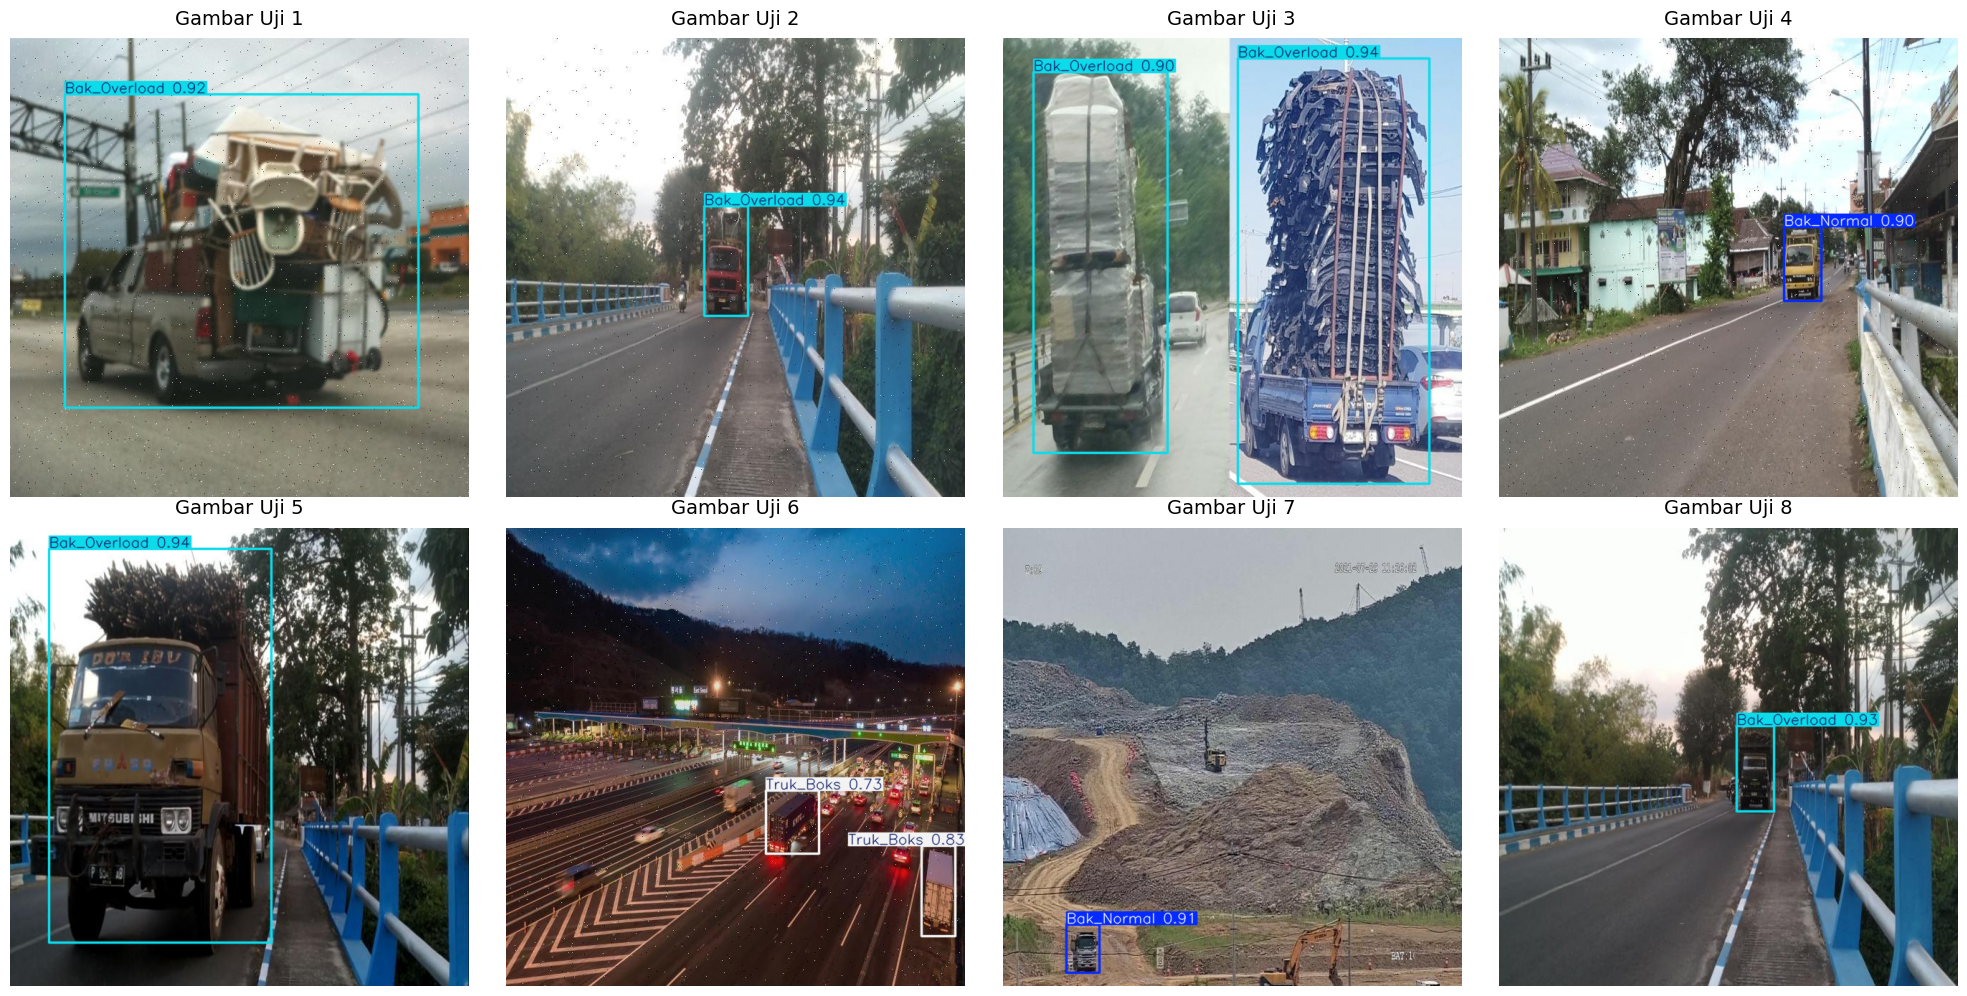


🎯 Prediksi visual selesai! Jika ingin melihat sampel gambar yang lain, cukup jalankan ulang cell ini.


In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("1. Memuat model terbaik (best.pt) dari Google Drive...")
# Path model SUDAH DIREVISI ke Google Drive
best_model = YOLO('/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil/weights/best.pt')

print("\n2. Mengambil 8 gambar acak dari folder Test...")
# Path dataset SUDAH DIREVISI (menggantikan MAIN_DIR yang error)
test_images_dir = '/content/data-indah-2/test/images'

# Mengambil semua file gambar di dalam folder test
all_test_images = [f for f in os.listdir(test_images_dir) if f.endswith('.jpg')]

# Mengambil 8 gambar secara acak (Pastikan folder test minimal punya 8 gambar)
jumlah_sample = min(8, len(all_test_images))
random_test_images = random.sample(all_test_images, jumlah_sample)

print("3. Melakukan deteksi dan mencetak kotak bounding box...\n")

# Siapkan kanvas (figure) untuk gambar (2 baris x 4 kolom)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Jika gambar kurang dari 8, kita ratakan array axes agar tidak error
axes = axes.flatten()

for i, img_name in enumerate(random_test_images):
    img_path = os.path.join(test_images_dir, img_name)

    # Eksekusi deteksi! conf=0.5 (Hanya tampilkan deteksi yang yakin di atas 50%)
    results = best_model.predict(source=img_path, imgsz=640, conf=0.5, verbose=False)

    # Menggambar bounding box ke atas gambar
    annotated_img = results[0].plot()

    # Konversi format warna dari BGR (OpenCV) ke RGB (Matplotlib)
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    ax = axes[i]
    ax.imshow(annotated_img_rgb)
    ax.axis('off')
    ax.set_title(f"Gambar Uji {i+1}", fontsize=14, pad=10)

# Sembunyikan sisa kanvas jika gambar kurang dari 8
for j in range(i + 1, 8):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("\n🎯 Prediksi visual selesai! Jika ingin melihat sampel gambar yang lain, cukup jalankan ulang cell ini.")

CELL 9: Deteksi

In [ ]:
from ultralytics import YOLO
import os
import subprocess
from google.colab import files
from IPython.display import Video, Image, display

print("1. Memuat 'otak' model terbaik kita dari Google Drive...")
# Path model SUDAH DIREVISI ke Google Drive agar tidak FileNotFoundError
model_path = '/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil/weights/best.pt'
best_model = YOLO(model_path)

# Folder khusus untuk menyimpan hasil deteksi di Google Drive
folder_simpan_drive = '/content/drive/MyDrive/Evaluasi_ODOL/Hasil_Deteksi_Bebas'
os.makedirs(folder_simpan_drive, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'

    # Deteksi ekstensi file (huruf kecil semua agar aman)
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    # 3. JALANKAN PREDIKSI (PENGATURAN STANDAR)
    # conf=0.25 (Standar bawaan YOLO yang stabil)
    # agnostic_nms=True (Mencegah dua kotak beda kelas menumpuk di satu truk)
    results = best_model.predict(
        source=input_path,
        conf=0.25,
        agnostic_nms=True,
        save=True,
        project=folder_simpan_drive,
        name='tes_bebas_standar',
        exist_ok=True
    )
    save_dir = results[0].save_dir

    print("\n" + "="*50)
    print("🎯 PROSES DETEKSI SELESAI!")
    print("="*50)

    # 4. TAMPILKAN HASIL BERDASARKAN TIPE FILE
    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # --- JIKA FOTO ---
        output_image_path = os.path.join(save_dir, file_name)

        # Khusus format webp, sistem YOLO biasanya menyimpannya otomatis sebagai .jpg
        if ext == 'webp' and not os.path.exists(output_image_path):
            output_image_path = output_image_path.replace('.webp', '.jpg')

        print("Menampilkan Hasil Foto:\n")
        display(Image(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan permanen di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # --- JIKA VIDEO ---
        print("[2/2] Mengonversi video agar bisa diputar di Colab...")

        # YOLO menyimpan video mentah sebagai .avi
        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(save_dir, f"{nama_tanpa_ext}.avi")

        # Lokasi video MP4 final di Google Drive
        mp4_final_path = os.path.join(folder_simpan_drive, f"{nama_tanpa_ext}_FINAL.mp4")

        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        # Konversi cepat dengan ffmpeg
        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        print("🎬 Video siap diputar!\n")
        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")

    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

1. Memuat 'otak' model terbaik kita dari Google Drive...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving contoh tes.mp4 to contoh tes.mp4

[1/2] Memproses file: contoh tes.mp4...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/47) /content/contoh tes.mp4: 640x480 1 Bak_Normal, 41.3ms
video 1/1 (frame 2/47) /content/contoh tes.mp4: 640x480 1 Bak_Normal, 6.5ms
video 1/1 (frame 3/47) /content/contoh tes.mp4: 640x480 1 Bak_Normal, 6.1ms
video 1/1 (frame 4/47) /content/contoh tes.mp4: 640x480 1 Bak_Normal, 5.9ms
video 1/1 (frame 5/47) /content/contoh tes.mp4: 640x480 1 Bak_Normal, 6.


✅ Video aman tersimpan permanen di: /content/drive/MyDrive/Evaluasi_ODOL/Hasil_Deteksi_Bebas/contoh tes_FINAL.mp4


1. Memuat 'otak' model terbaik kita dari Google Drive...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving sewa-engkel-truk-box-harga-murah-og.jpg to sewa-engkel-truk-box-harga-murah-og.jpg

[1/2] Memproses file: sewa-engkel-truk-box-harga-murah-og.jpg...

image 1/1 /content/sewa-engkel-truk-box-harga-murah-og.jpg: 352x640 1 Truk_Boks, 40.6ms
Speed: 2.7ms preprocess, 40.6ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/drive/MyDrive/Evaluasi_ODOL/Hasil_Deteksi_Bebas/tes_bebas_standar

🎯 PROSES DETEKSI SELESAI!
Menampilkan Hasil Foto:



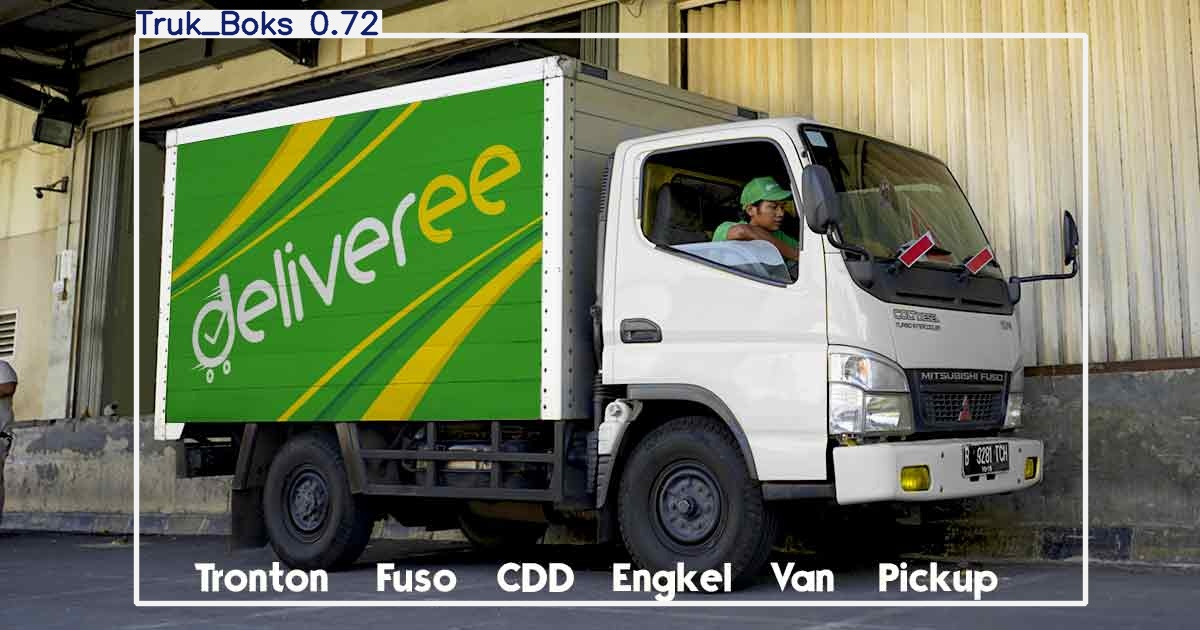


✅ File aman tersimpan permanen di: /content/drive/MyDrive/Evaluasi_ODOL/Hasil_Deteksi_Bebas/tes_bebas_standar/sewa-engkel-truk-box-harga-murah-og.jpg


In [ ]:
from ultralytics import YOLO
import os
import subprocess
from google.colab import files
from IPython.display import Video, Image, display

print("1. Memuat 'otak' model terbaik kita dari Google Drive...")
# Path model SUDAH DIREVISI ke Google Drive agar tidak FileNotFoundError
model_path = '/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil/weights/best.pt'
best_model = YOLO(model_path)

# Folder khusus untuk menyimpan hasil deteksi di Google Drive
folder_simpan_drive = '/content/drive/MyDrive/Evaluasi_ODOL/Hasil_Deteksi_Bebas'
os.makedirs(folder_simpan_drive, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'

    # Deteksi ekstensi file (huruf kecil semua agar aman)
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    # 3. JALANKAN PREDIKSI (PENGATURAN STANDAR)
    # conf=0.25 (Standar bawaan YOLO yang stabil)
    # agnostic_nms=True (Mencegah dua kotak beda kelas menumpuk di satu truk)
    results = best_model.predict(
        source=input_path,
        conf=0.25,
        agnostic_nms=True,
        save=True,
        project=folder_simpan_drive,
        name='tes_bebas_standar',
        exist_ok=True
    )
    save_dir = results[0].save_dir

    print("\n" + "="*50)
    print("🎯 PROSES DETEKSI SELESAI!")
    print("="*50)

    # 4. TAMPILKAN HASIL BERDASARKAN TIPE FILE
    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # --- JIKA FOTO ---
        output_image_path = os.path.join(save_dir, file_name)

        # Khusus format webp, sistem YOLO biasanya menyimpannya otomatis sebagai .jpg
        if ext == 'webp' and not os.path.exists(output_image_path):
            output_image_path = output_image_path.replace('.webp', '.jpg')

        print("Menampilkan Hasil Foto:\n")
        display(Image(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan permanen di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # --- JIKA VIDEO ---
        print("[2/2] Mengonversi video agar bisa diputar di Colab...")

        # YOLO menyimpan video mentah sebagai .avi
        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(save_dir, f"{nama_tanpa_ext}.avi")

        # Lokasi video MP4 final di Google Drive
        mp4_final_path = os.path.join(folder_simpan_drive, f"{nama_tanpa_ext}_FINAL.mp4")

        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        # Konversi cepat dengan ffmpeg
        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        print("🎬 Video siap diputar!\n")
        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")

    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

CELL 10: Persiapan Ekspor (Unduh Model)

In [ ]:
from google.colab import files

# Lokasi model terbaikmu di Drive
path_model = '/content/drive/MyDrive/Evaluasi_ODOL/YOLOv8_Hasil/weights/best.pt'

print("Menyiapkan file best.pt untuk diunduh ke laptop...")
files.download(path_model)
print("Silakan cek folder 'Downloads' di laptop kamu!")

Menyiapkan file best.pt untuk diunduh ke laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Silakan cek folder 'Downloads' di laptop kamu!
